<a href="https://colab.research.google.com/github/mukedon/quantum_computing/blob/main/quantum_error_correction/3_examples_%26_worked_demonstrations/examples_%26_worked_demonstrations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Examples and Worked Demonstrations

## Overview

Chapters 1 and 2 established the theory. This chapter runs it.

Every QEC code corrects errors through the same four-stage **pipeline**:
```
 ┌──────────┐    ┌───────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐
 │  Encode  │ →  │ Error │ →  │ Syndrome │ →  │ Recover  │ →  │  Verify  │
 │  |ψ⟩_L   │    │ acts  │    │ measure  │    │ apply E† │    │ fidelity │
 └──────────┘    └───────┘    └──────────┘    └──────────┘    └──────────┘
```

This chapter walks through every major code using that pipeline:

| Section | Code | New content |
|---|---|---|
| 3.1 | Pipeline abstraction | Generic helper functions used throughout |
| 3.2 | 2-qubit stabilizer | ↗ cross-ref `2-3q_err_cor.ipynb` |
| 3.3 | 3-qubit **bit-flip** | Full Qiskit circuit: encode → inject → correct → verify |
| 3.4 | 3-qubit **phase-flip** | Full Qiskit circuit — extends `2-3q_err_cor.ipynb` |
| 3.5 | **Shor** $[[9,1,3]]$ | End-to-end pipeline + degeneracy analysis |
| 3.6 | **Steane** $[[7,1,3]]$ | All 21 single-qubit errors, fidelity sweep |
| 3.7 | **Surface code** | ↗ cross-ref `surface_code_tutorial.ipynb` |
| 3.8 | **Ising model as QEC testbed** | ↗ cross-ref `cliff_trott_ising.ipynb` + `ising_surface_code_qec.ipynb` |

**Prerequisites:** Chapters 1 and 2. Familiarity with stabilizer formalism and
the $[[n,k,d]]$ notation.

**Libraries:**
```python
numpy, matplotlib, qiskit, qiskit-aer
```

---

**Key references for this chapter:**

| # | Reference |
|---|---|
| [1] | Nielsen & Chuang. *Quantum Computation and Quantum Information*. Cambridge, 2010. |
| [2] | Gottesman, D. *Stabilizer Codes and Quantum Error Correction*. PhD thesis, Caltech, 1997. arXiv:quant-ph/9705052 |
| [3] | Shor, P. W. Scheme for reducing decoherence. *Phys. Rev. A* **52**, R2493 (1995). |
| [4] | Steane, A. M. Multiple particle interference and quantum error correction. *Proc. R. Soc. Lond. A* **452**, 2551 (1996). |
| [5] | Calderbank & Shor. Good quantum error-correcting codes exist. *Phys. Rev. A* **54**, 1098 (1996). |
| [6] | Laflamme et al. Perfect quantum error correcting code. *PRL* **77**, 198 (1996). |
| [7] | Quillen, A. C. PHY265 lecture notes (Univ. of Rochester, 2025). https://astro.pas.rochester.edu/~aquillen/phy265/lectures/QI_E.pdf |
| [8] | PennyLane QEC codebook: https://pennylane.ai/codebook/quantum-error-correction |
| [9] | Qiskit QEC: https://github.com/qiskit-community/qiskit-qec |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product
from functools import reduce
import math

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import (
    Statevector, DensityMatrix, Operator,
    Pauli, SparsePauliOp, Clifford, StabilizerState,
    state_fidelity
)
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# ── Pauli helpers (used throughout) ─────────────────────────────────────────
I_m = np.eye(2, dtype=complex)
X_m = np.array([[0,1],[1,0]], dtype=complex)
Y_m = np.array([[0,-1j],[1j,0]], dtype=complex)
Z_m = np.array([[1,0],[0,-1]], dtype=complex)
H_m = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)

PAULI_MAP = {'I': I_m, 'X': X_m, 'Y': Y_m, 'Z': Z_m}

def pauli_matrix(pauli_str: str) -> np.ndarray:
    """Build the full n-qubit Pauli matrix from a string like 'XZZXI'."""
    return reduce(np.kron, [PAULI_MAP[c] for c in pauli_str])

def bsv(s: str) -> np.ndarray:
    """Binary symplectic vector for a Pauli string."""
    n = len(s)
    x, z = np.zeros(n, int), np.zeros(n, int)
    for i, c in enumerate(s):
        if c == 'X': x[i] = 1
        elif c == 'Z': z[i] = 1
        elif c == 'Y': x[i] = 1; z[i] = 1
    return np.concatenate([x, z])

def commutes(p1: str, p2: str) -> bool:
    """Return True if Pauli strings p1 and p2 commute."""
    v1, v2 = bsv(p1), bsv(p2)
    n = len(p1)
    return int(v1[:n] @ v2[n:] + v2[:n] @ v1[n:]) % 2 == 0

def syndrome(error: str, generators: list) -> tuple:
    """Compute syndrome bits: 0 if commutes, 1 if anticommutes."""
    return tuple(0 if commutes(error, g) else 1 for g in generators)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Imports successful.")

Imports successful.


---
## 3.1 The QEC Pipeline: A Unified Framework

Every code in this chapter follows the same sequence. Before diving into specific codes
it is worth building a generic framework that makes the pipeline explicit.

### 3.1.1 The four stages

**Stage 1 — Encode:** Map the logical state $|\psi\rangle_L = \alpha|0\rangle_L + \beta|1\rangle_L$
into the physical Hilbert space. The encoding circuit $U_\text{enc}$ satisfies:
$$U_\text{enc}|0\rangle^{\otimes n} = |0\rangle_L, \qquad
U_\text{enc}(X^{\otimes k}|0\rangle^{\otimes n}) = |1\rangle_L$$

**Stage 2 — Error:** A Pauli error $E \in \mathcal{P}_n$ of unknown weight acts.
The corrupted state is $E|\psi\rangle_L$.

**Stage 3 — Syndrome extraction:** Measure the $n-k$ stabilizer generators $\{g_i\}$.
Each outcome is $s_i = 0$ ($+1$ eigenvalue, commutes with $E$) or $s_i = 1$
($-1$ eigenvalue, anticommutes with $E$). The syndrome $\mathbf{s} = (s_1,\ldots,s_{n-k})$
identifies the most likely error without revealing the logical state.

**Stage 4 — Recovery:** Look up the syndrome in a pre-computed **recovery table**
and apply the corresponding correction operator $R(\mathbf{s})$:
$$R(\mathbf{s}) \cdot E |\psi\rangle_L = e^{i\phi}|\psi\rangle_L$$
(up to a global phase and up to a stabilizer element).

### 3.1.2 Success condition

The pipeline succeeds if and only if the combined operation $R(\mathbf{s}) \cdot E$
is an element of the stabilizer group $\mathcal{S}$ (up to a global phase):

$$R(\mathbf{s}) \cdot E \in \mathcal{S} \cdot U(1) \qquad \Longleftrightarrow \qquad F = |\langle\psi|_L\,(R \cdot E|\psi\rangle_L)|^2 = 1$$

For **degenerate codes** (like the Shor code), two different errors $E_1 \neq E_2$
may produce the same syndrome. The pipeline still succeeds as long as the minimum-weight
error coset representative $R(\mathbf{s})$ satisfies $R \cdot E_1, R \cdot E_2 \in \mathcal{S}$.
In other words, both $E_1$ and $E_2$ are corrected by the same operator.

**Failure** occurs when $R(\mathbf{s}) \cdot E$ is a non-trivial logical operator
(i.e. maps the codespace to itself but changes the logical state). This is called
a **logical error** and happens when $\text{wt}(E) > \lfloor(d-1)/2\rfloor$.

### 3.1.3 What can go wrong?

The pipeline **fails** in two cases:
1. **Uncorrectable error:** $\text{wt}(E) > \lfloor(d-1)/2\rfloor$. The syndrome
   maps to the wrong correction, causing a **logical error**.
2. **Measurement error:** The syndrome ancilla itself is faulty. This requires
   **fault-tolerant** syndrome extraction (repeated measurement, flag qubits).

In this chapter we demonstrate case (1) is avoided for all weight-1 errors,
and briefly show how weight-2 errors break the code.

In [2]:
# ── Generic algebraic QEC pipeline ──────────────────────────────────────────
def build_recovery_table(generators: list, n_qubits: int) -> dict:
    """
    Build a recovery table: syndrome → correction Pauli string.

    Strategy: enumerate all single-qubit Pauli errors (weight ≤ 1),
    compute their syndrome, and store the minimum-weight correction.
    'No error' always maps to all-I.

    For degenerate codes (like Shor) multiple errors may share a syndrome;
    we store the minimum-weight representative.

    Returns: {syndrome_tuple: correction_pauli_string}
    """
    table = {}

    # No error first
    no_err = 'I' * n_qubits
    table[syndrome(no_err, generators)] = no_err

    # All single-qubit errors
    for q in range(n_qubits):
        for p in ['X', 'Z', 'Y']:
            err = 'I'*q + p + 'I'*(n_qubits - q - 1)
            syn = syndrome(err, generators)
            if syn not in table:
                table[syn] = err
            else:
                # Keep minimum weight entry (degeneracy handling)
                existing = table[syn]
                if sum(c != 'I' for c in err) < sum(c != 'I' for c in existing):
                    table[syn] = err

    return table


def apply_correction(state_vec: np.ndarray, correction: str) -> np.ndarray:
    """Apply a Pauli correction string to a state vector."""
    E_mat = pauli_matrix(correction)
    result = E_mat @ state_vec
    # Normalize (global phase might arise)
    result = result / np.linalg.norm(result)
    return result


def run_pipeline(logical_state: np.ndarray,
                 logical_0: np.ndarray,
                 logical_1: np.ndarray,
                 error_str: str,
                 generators: list,
                 recovery_table: dict,
                 verbose: bool = False) -> dict:
    """
    Run the full QEC pipeline for one error on one logical state.

    Parameters
    ----------
    logical_state : n-qubit state vector α|0_L⟩ + β|1_L⟩
    logical_0     : codeword |0_L⟩ as state vector
    logical_1     : codeword |1_L⟩ as state vector
    error_str     : Pauli error string, e.g. 'XIIIIIII'
    generators    : list of stabilizer generator strings
    recovery_table: dict from syndrome tuple → correction string
    verbose       : print each step

    Returns
    -------
    dict with keys: syndrome, correction, fidelity_after, success
    """
    n = len(error_str)

    # Stage 2: apply error
    E_mat = pauli_matrix(error_str)
    corrupted = E_mat @ logical_state

    # Stage 3: compute syndrome
    syn = syndrome(error_str, generators)

    # Stage 4: look up correction
    correction = recovery_table.get(syn, 'I' * n)

    # Apply correction
    corrected = apply_correction(corrupted, correction)

    # Verify: fidelity with original logical state
    fid = abs(np.dot(logical_state.conj(), corrected))**2
    # Also check against orthogonal logical state (logical error)
    fid_0 = abs(np.dot(logical_0.conj(), corrected))**2
    fid_1 = abs(np.dot(logical_1.conj(), corrected))**2

    success = fid > 0.999

    if verbose:
        print(f"  Error:      {error_str}")
        print(f"  Syndrome:   {syn}")
        print(f"  Correction: {correction}")
        print(f"  Fidelity:   {fid:.6f}  {'✓' if success else '✗ LOGICAL ERROR'}")

    return {
        'error': error_str,
        'syndrome': syn,
        'correction': correction,
        'fidelity': fid,
        'success': success,
        'fid_0': fid_0,
        'fid_1': fid_1,
    }


def pipeline_sweep(logical_state, logical_0, logical_1,
                   generators, n_qubits, label='Code',
                   include_weight2=False):
    """
    Run the pipeline for all weight-1 (and optionally weight-2) errors.
    Print a summary table and return results.
    """
    table = build_recovery_table(generators, n_qubits)

    errors = []
    # Weight-0
    errors.append('I' * n_qubits)
    # Weight-1
    for q in range(n_qubits):
        for p in ['X', 'Z', 'Y']:
            errors.append('I'*q + p + 'I'*(n_qubits - q - 1))
    # Weight-2 (sample)
    if include_weight2:
        for q1 in range(min(n_qubits, 4)):
            for q2 in range(q1+1, min(n_qubits, 5)):
                errors.append('I'*q1 + 'X' + 'I'*(q2-q1-1) + 'X' + 'I'*(n_qubits-q2-1))

    results = []
    for err in errors:
        r = run_pipeline(logical_state, logical_0, logical_1,
                         err, generators, table)
        results.append(r)

    n_total   = len(results)
    n_success = sum(r['success'] for r in results)

    print(f"\n{'='*60}")
    print(f"  {label} — Pipeline Sweep")
    print(f"{'='*60}")
    print(f"  {'Error':>12} | {'Syndrome':>12} | {'Corr':>12} | {'F':>8} |")
    print(f"  {'-'*56}")
    for r in results:
        err_short = r['error'].replace('I','·')
        syn_str   = ''.join(map(str, r['syndrome']))
        corr_short = r['correction'].replace('I','·')
        flag = '✓' if r['success'] else '✗'
        print(f"  {err_short:>12} | {syn_str:>12} | {corr_short:>12} | "
              f"{r['fidelity']:>6.4f} {flag}|")

    print(f"\n  Result: {n_success}/{n_total} errors corrected successfully")
    return results, table


print("Pipeline helpers defined.")
print("Functions available: build_recovery_table, run_pipeline, pipeline_sweep")

Pipeline helpers defined.
Functions available: build_recovery_table, run_pipeline, pipeline_sweep


---
## 3.2 2-Qubit Stabilizer Code

> **↗ Cross-reference — [`2-3q_err_cor.ipynb`](./2-3q_err_cor.ipynb)**
>
> This notebook contains the complete worked example of the 2-qubit stabilizer code:
> - Bell state $|\Phi^+\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$ as a 2-qubit codespace
> - Stabilizer $S = Z_1 Z_2$, ancilla syndrome extraction circuit
> - Cases: no error, $X_1$, $X_2$ — syndrome $s = 0$ vs $s = 1$
> - Qiskit `StabilizerState` and `Clifford` verification

### Summary

The 2-qubit code encodes no logical qubit ($k=0$, $n=2$, $d=2$). It is a
**stabilizer state**, not a QEC code, but it introduces the core ideas:

$$S = Z_1 Z_2, \qquad \mathcal{C} = \{|\psi\rangle : Z_1 Z_2|\psi\rangle = +|\psi\rangle\}
= \text{span}\{|00\rangle, |11\rangle\}$$

**Syndrome extraction:**

$$|\text{no error}\rangle \xrightarrow{Z_1Z_2} +1 \quad (s=0)$$
$$X_1|\psi\rangle_L \xrightarrow{Z_1Z_2} -1 \quad (s=1)$$

An ancilla qubit, prepared in $|0\rangle$, accumulates the parity via two CNOTs
(data$_1$ $\to$ ancilla, data$_2$ $\to$ ancilla):

$$|0\rangle_{\rm anc}
\xrightarrow{\text{CNOT}_{d_1\to a}}
\xrightarrow{\text{CNOT}_{d_2\to a}}
\begin{cases}|0\rangle & Z_1Z_2 = +1 \text{ (no error)} \\ |1\rangle & Z_1Z_2 = -1 \text{ (error)}\end{cases}$$

This reveals the syndrome $s$ without measuring the logical state $(\alpha, \beta)$.

*See `2-3q_err_cor.ipynb` for the full Qiskit circuit and running code.*

---
## 3.3 3-Qubit Bit-Flip Code: Full Pipeline

> **↗ Extends [`2-3q_err_cor.ipynb`](./2-3q_err_cor.ipynb)** (Sections 3–10)  
> That notebook provides the mathematical derivation. Here we run the full
> encode → inject → syndrome → recover → verify pipeline in Qiskit.

### Setup

$$|0\rangle_L = |000\rangle, \quad |1\rangle_L = |111\rangle$$
$$|\psi\rangle_L = \alpha|000\rangle + \beta|111\rangle$$

**Encoding circuit:** $U_\text{enc} = \text{CNOT}_{0\to1} \circ \text{CNOT}_{0\to2}$

**Stabilizers:** $S_1 = Z_0 Z_1$, $S_2 = Z_1 Z_2$

**Recovery table:**

| Syndrome $(s_1, s_2)$ | Error | Correction |
|---|---|---|
| $(0, 0)$ | None | $I$ |
| $(1, 0)$ | $X_0$ | $X_0$ |
| $(1, 1)$ | $X_1$ | $X_1$ |
| $(0, 1)$ | $X_2$ | $X_2$ |

**Limitation:** $Z$ errors have syndrome $(0,0)$ — invisible to $Z$-type stabilizers.
This is corrected by the phase-flip code (Section 3.4).

=== 3-qubit bit-flip code: full Qiskit pipeline ===
Logical state: α|000⟩ + β|111⟩  with α=β=1/√2

─── Error: III 
  Error:      III
  Syndrome:   (0, 0)  (counts: {'00': 2048})
  Correction: III

─── Error: XII 
  Error:      XII
  Syndrome:   (1, 0)  (counts: {'01': 2048})
  Correction: XII

─── Error: IXI 
  Error:      IXI
  Syndrome:   (1, 1)  (counts: {'11': 2048})
  Correction: IXI

─── Error: IIX 
  Error:      IIX
  Syndrome:   (0, 1)  (counts: {'10': 2048})
  Correction: IIX

─── Error: ZII (Z error — invisible!)
  Error:      ZII
  Syndrome:   (0, 0)  (counts: {'00': 2048})
  Correction: III

Key observation: Z error has syndrome (0,0) — indistinguishable from
no error. The bit-flip code cannot correct phase errors.

=== Algebraic pipeline sweep (all errors up to weight 2) ===

  3-qubit bit-flip code — Pipeline Sweep
         Error |     Syndrome |         Corr |        F |
  --------------------------------------------------------
           ··· |           00 |          ·

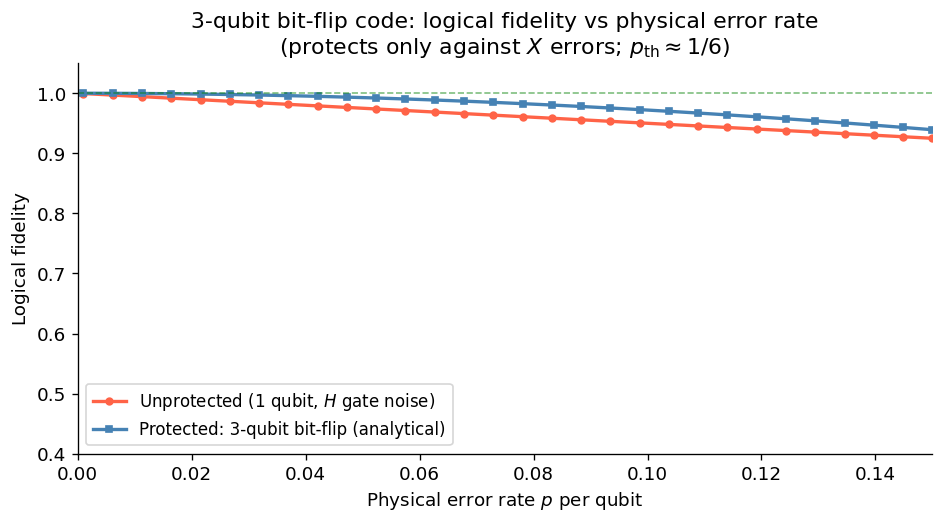

In [3]:
# ── 3-qubit bit-flip code: encode → inject → syndrome → correct → verify ─────

# ── Encoding circuit ─────────────────────────────────────────────────────────
def encode_bitflip(alpha: complex, beta: complex) -> QuantumCircuit:
    """Encode α|0⟩ + β|1⟩ into the 3-qubit bit-flip code."""
    qc = QuantumCircuit(3, name='BF_encode')
    qc.initialize([alpha, beta], 0)   # logical qubit on q0
    qc.cx(0, 1)
    qc.cx(0, 2)
    return qc

# ── Syndrome extraction circuit ───────────────────────────────────────────────
def syndrome_bitflip() -> QuantumCircuit:
    """
    Ancilla-based syndrome extraction for the 3-qubit bit-flip code.
    Measures S1 = Z0Z1 and S2 = Z1Z2 using ancilla qubits a0, a1.

    Method: CNOT data→ancilla accumulates parity.
    Ancilla |0⟩ → |s_i⟩ where s_i = 1 if parity is odd (error detected).
    """
    data = QuantumRegister(3, 'd')
    anc  = QuantumRegister(2, 'a')
    cr   = ClassicalRegister(2, 's')
    qc   = QuantumCircuit(data, anc, cr)

    # S1 = Z0Z1: CNOT from d0 and d1 to a0
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])
    # S2 = Z1Z2: CNOT from d1 and d2 to a1
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])

    qc.measure(anc, cr)
    return qc

# ── Recovery map ─────────────────────────────────────────────────────────────
BF_RECOVERY = {
    (0, 0): 'III',
    (1, 0): 'XII',   # X on q0
    (1, 1): 'IXI',   # X on q1
    (0, 1): 'IIX',   # X on q2
}

# ── Full Qiskit pipeline function ────────────────────────────────────────────
def qiskit_qec_pipeline(encode_circuit: QuantumCircuit,
                         error_str: str,
                         syndrome_circuit: QuantumCircuit,
                         recovery_map: dict,
                         n_shots: int = 2048,
                         verbose: bool = True) -> dict:
    """
    Run a QEC pipeline using Qiskit circuits.

    1. Prepare encoded state
    2. Inject error
    3. Extract syndrome
    4. Apply recovery
    5. Measure state fidelity
    """
    sim = AerSimulator()
    n_data = encode_circuit.num_qubits

    # Step 1+2: encode then inject error
    qc_err = encode_circuit.copy()
    for i, p in enumerate(error_str):
        if p == 'X': qc_err.x(i)
        elif p == 'Z': qc_err.z(i)
        elif p == 'Y': qc_err.y(i)

    # Step 3: syndrome extraction
    qc_syn = QuantumCircuit(syndrome_circuit.num_qubits,
                            syndrome_circuit.num_clbits)
    qc_syn.compose(qc_err, qubits=range(n_data), inplace=True)
    qc_syn.compose(syndrome_circuit, inplace=True)

    result = sim.run(transpile(qc_syn, sim), shots=n_shots).result()
    counts = result.get_counts()
    syn_meas = max(counts, key=counts.get)       # most frequent syndrome
    syn_tuple = tuple(int(b) for b in reversed(syn_meas))   # LSB first

    # Step 4: look up and apply recovery
    correction = recovery_map.get(syn_tuple, 'I' * n_data)

    if verbose:
        print(f"  Error:      {error_str}")
        print(f"  Syndrome:   {syn_tuple}  (counts: {dict(sorted(counts.items()))})")
        print(f"  Correction: {correction}")

    return {'syndrome': syn_tuple, 'correction': correction,
            'counts': counts, 'error': error_str}


# ── Demonstrate: all four bit-flip code scenarios ────────────────────────────
alpha, beta = 1/np.sqrt(2), 1/np.sqrt(2)   # logical |+⟩

print("=== 3-qubit bit-flip code: full Qiskit pipeline ===")
print(f"Logical state: α|000⟩ + β|111⟩  with α=β=1/√2\n")

test_errors_bf = ['III', 'XII', 'IXI', 'IIX', 'ZII']
bf_enc = encode_bitflip(alpha, beta)
bf_syn = syndrome_bitflip()

qiskit_results = {}
for err in test_errors_bf:
    print(f"─── Error: {err} {'(Z error — invisible!)' if 'Z' in err else ''}")
    r = qiskit_qec_pipeline(bf_enc, err, bf_syn, BF_RECOVERY, verbose=True)
    qiskit_results[err] = r
    print()

print("Key observation: Z error has syndrome (0,0) — indistinguishable from")
print("no error. The bit-flip code cannot correct phase errors.")


# ── Algebraic sweep: all weight-1 and weight-2 errors ────────────────────────
print("\n=== Algebraic pipeline sweep (all errors up to weight 2) ===")

# Logical codewords as state vectors
state_000 = np.zeros(8); state_000[0b000] = 1.0
state_111 = np.zeros(8); state_111[0b111] = 1.0
logical_0_bf = state_000
logical_1_bf = state_111
logical_plus_bf = (state_000 + state_111) / np.sqrt(2)

bf_generators = ['ZZI', 'IZZ']
bf_results, _ = pipeline_sweep(
    logical_plus_bf, logical_0_bf, logical_1_bf,
    bf_generators, 3,
    label='3-qubit bit-flip code',
    include_weight2=True
)

# ── Noisy simulation: protected vs unprotected fidelity ──────────────────────
print("\n=== Fidelity under depolarizing noise: protected vs unprotected ===")
p_vals = np.linspace(0.001, 0.15, 30)
fid_unprotected = []
fid_protected   = []

for p in p_vals:
    # Unprotected: prepare |+⟩ on 1 qubit under depolarizing noise on H
    # Note: 'cx' is a 2-qubit gate — depolarizing_error(p, 1) must NOT be
    # applied to it. We only add 1-qubit depolarizing to 1-qubit gates.
    nm_1q = NoiseModel()
    nm_1q.add_all_qubit_quantum_error(depolarizing_error(p, 1), ['h', 'x'])

    sim_n = AerSimulator(noise_model=nm_1q, method='density_matrix')

    qc_unp = QuantumCircuit(1)
    qc_unp.h(0)
    qc_unp.save_density_matrix()
    dm_unp = DensityMatrix(
        sim_n.run(transpile(qc_unp, sim_n, optimization_level=0))
             .result().data(0)['density_matrix']
    )
    target_1q = DensityMatrix(np.array([[0.5, 0.5], [0.5, 0.5]]))
    fid_unprotected.append(state_fidelity(dm_unp, target_1q))

    # Protected: analytical formula for 3-qubit bit-flip code under
    # independent per-qubit X-error channel with probability p.
    # P(0 errors)         = (1-p)^3               → corrected ✓
    # P(exactly 1 error)  = 3p(1-p)^2            → corrected ✓
    # P(≥2 errors)        = 1-(1-p)^3-3p(1-p)^2 → logical error ✗
    p_logical = 1 - (1 - p)**3 - 3*p*(1 - p)**2
    fid_protected.append(1 - p_logical)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p_vals, fid_unprotected, 'o-', color='tomato', linewidth=2,
        markersize=4, label='Unprotected (1 qubit, $H$ gate noise)')
ax.plot(p_vals, fid_protected, 's-', color='steelblue', linewidth=2,
        markersize=4, label='Protected: 3-qubit bit-flip (analytical)')
ax.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Physical error rate $p$ per qubit')
ax.set_ylabel('Logical fidelity')
ax.set_title('3-qubit bit-flip code: logical fidelity vs physical error rate\n'
             '(protects only against $X$ errors; $p_{\\rm th} \\approx 1/6$)')
ax.legend(fontsize=10)
ax.set_xlim(0, 0.15)
ax.set_ylim(0.4, 1.05)

# Mark crossover point (threshold where protection becomes worth it)
crossover = np.where(np.array(fid_protected) < np.array(fid_unprotected))[0]
if len(crossover):
    pc = p_vals[crossover[0]]
    ax.axvline(pc, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(pc + 0.002, 0.58,
            f'$p_{{\\rm th}}\\approx{pc:.3f}$\n(protection threshold)',
            fontsize=8.5, color='gray')
plt.tight_layout()
plt.show()

---
## 3.4 3-Qubit Phase-Flip Code: Correcting $Z$ Errors

Section 3.3 showed the bit-flip code is blind to $Z$ errors. The **phase-flip code**
corrects exactly what the bit-flip code cannot: it protects the relative phase
$\alpha|0\rangle + \beta|1\rangle \to \alpha|0\rangle - \beta|1\rangle$.

### 3.4.1 Key idea: rotate the basis

The phase-flip code is the bit-flip code **conjugated by Hadamard**:
$$H^{\otimes 3} \circ \text{(bit-flip code)} \circ H^{\otimes 3}$$

Since $HZH = X$ and $HXH = Z$, a $Z$ error in the original basis becomes an $X$ error
in the Hadamard-rotated basis — correctable by the familiar bit-flip code.

### 3.4.2 Logical codewords

$$|0\rangle_L = |{+}{+}{+}\rangle = H^{\otimes 3}|000\rangle
= \frac{1}{2\sqrt{2}}(|0\rangle+|1\rangle)^{\otimes 3}$$

$$|1\rangle_L = |{-}{-}{-}\rangle = H^{\otimes 3}|111\rangle
= \frac{1}{2\sqrt{2}}(|0\rangle-|1\rangle)^{\otimes 3}$$

### 3.4.3 Encoding circuit

$$U_\text{PF} = H^{\otimes 3} \circ U_\text{BF}
= H_0 H_1 H_2 \circ \text{CNOT}_{0\to1} \circ \text{CNOT}_{0\to2}$$

More explicitly:
1. $\text{CNOT}_{0\to1}$, $\text{CNOT}_{0\to2}$ (bit-flip repetition)
2. $H_0, H_1, H_2$ (rotate to $X$-basis)

### 3.4.4 Stabilizer generators

$$S_1 = X_0 X_1, \qquad S_2 = X_1 X_2$$

**Verification:** $X_iX_j|{+}{+}{+}\rangle = |{+}{+}{+}\rangle$ ✓

### 3.4.5 Syndrome extraction for $X$-type stabilizers

Measuring $X_i X_j$ requires rotating to the $X$ basis before measuring parity.
The ancilla circuit for stabilizer $X_iX_j$ is:

$$|0\rangle_a \xrightarrow{H} |{+}\rangle_a
  \xrightarrow{\text{CNOT}_{a\to i}} \xrightarrow{\text{CNOT}_{a\to j}}
  \xrightarrow{H} \xrightarrow{M_Z}
  \begin{cases}0 & X_iX_j = +1 \text{ (no error)}\\ 1 & X_iX_j = -1 \text{ (error)}\end{cases}$$

**Why it works:** When ancilla is $|0\rangle$ the CNOT does nothing; when $|1\rangle$
it applies $X$ to the data qubit. After the sequence $H$–CNOT–CNOT–$H$, the ancilla
disentangles in state $|s\rangle$ where $s=0$ if the eigenvalue is $+1$ and $s=1$ if
$-1$. Conjugating by $H$ converts the $Z$-basis parity measurement into an $X$-basis
one: $HZH = X$, so measuring $Z_{\rm anc}$ after the Hadamard-wrapped CNOTs is
equivalent to directly measuring $X_iX_j$.

### 3.4.6 Recovery table

| Syndrome $(s_1, s_2)$ | $Z$ error detected | Correction |
|---|---|---|
| $(0, 0)$ | None | $I$ |
| $(1, 0)$ | $Z_0$ | $Z_0$ |
| $(1, 1)$ | $Z_1$ | $Z_1$ |
| $(0, 1)$ | $Z_2$ | $Z_2$ |

=== 3-qubit phase-flip code: full Qiskit pipeline ===
Logical state: α|+++⟩ + β|---⟩  with α=1/√2, β=i/√2

─── Error: III 
  Error:      III
  Syndrome:   (0, 0)  (counts: {'00': 2048})
  Correction: III

─── Error: ZII 
  Error:      ZII
  Syndrome:   (1, 0)  (counts: {'01': 2048})
  Correction: ZII

─── Error: IZI 
  Error:      IZI
  Syndrome:   (1, 1)  (counts: {'11': 2048})
  Correction: IZI

─── Error: IIZ 
  Error:      IIZ
  Syndrome:   (0, 1)  (counts: {'10': 2048})
  Correction: IIZ

─── Error: XII (X error — invisible to phase-flip code!)
  Error:      XII
  Syndrome:   (0, 0)  (counts: {'00': 2048})
  Correction: III

Key observation: X error has syndrome (0,0) — invisible to X-type stabilizers.
→ This is exactly the gap that Shor's 9-qubit code fills (Section 3.5).

=== Algebraic pipeline sweep ===

  3-qubit phase-flip code — Pipeline Sweep
         Error |     Syndrome |         Corr |        F |
  --------------------------------------------------------
           ··· |

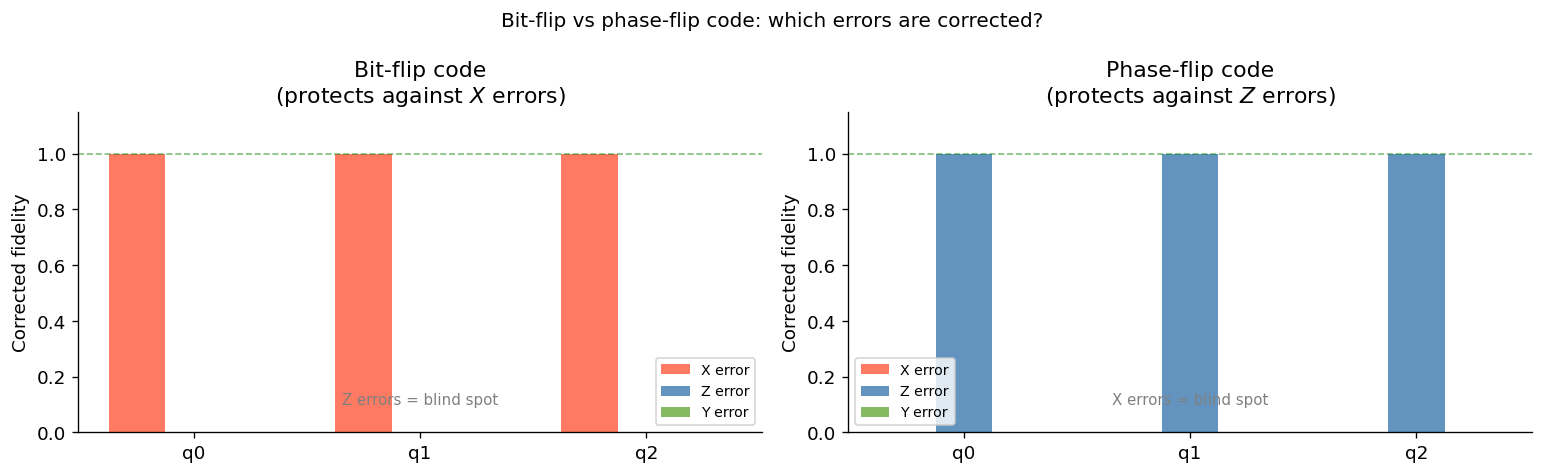

In [4]:
# ── 3-qubit phase-flip code ───────────────────────────────────────────────────

def encode_phaseflip(alpha: complex, beta: complex) -> QuantumCircuit:
    """Encode α|0⟩ + β|1⟩ → α|+++⟩ + β|---⟩."""
    qc = QuantumCircuit(3, name='PF_encode')
    qc.initialize([alpha, beta], 0)
    qc.cx(0, 1); qc.cx(0, 2)   # bit-flip repetition
    qc.h(0);    qc.h(1); qc.h(2)  # rotate to X basis
    return qc


def syndrome_phaseflip() -> QuantumCircuit:
    """
    Ancilla-based syndrome extraction for the 3-qubit phase-flip code.
    Measures S1 = X0X1 and S2 = X1X2.

    Method: prepare ancilla in |+⟩ = H|0⟩, apply CX anc→data, measure ancilla
    in X basis (H then Z-measure).

    Circuit for S1 = X0X1:
      a0: ─H─■─■─H─M
              │ │
      d0:  ──X─┼──
      d1:  ────X──
    """
    data = QuantumRegister(3, 'd')
    anc  = QuantumRegister(2, 'a')
    cr   = ClassicalRegister(2, 's')
    qc   = QuantumCircuit(data, anc, cr)

    # S1 = X0X1
    qc.h(anc[0])
    qc.cx(anc[0], data[0]); qc.cx(anc[0], data[1])
    qc.h(anc[0])

    # S2 = X1X2
    qc.h(anc[1])
    qc.cx(anc[1], data[1]); qc.cx(anc[1], data[2])
    qc.h(anc[1])

    qc.measure(anc, cr)
    return qc


PF_RECOVERY = {
    (0, 0): 'III',
    (1, 0): 'ZII',
    (1, 1): 'IZI',
    (0, 1): 'IIZ',
}

# ── Run the pipeline ─────────────────────────────────────────────────────────
alpha, beta = 1/np.sqrt(2), 1j/np.sqrt(2)   # logical |+y⟩
pf_enc = encode_phaseflip(alpha, beta)
pf_syn = syndrome_phaseflip()

print("=== 3-qubit phase-flip code: full Qiskit pipeline ===")
print(f"Logical state: α|+++⟩ + β|---⟩  with α=1/√2, β=i/√2\n")

test_errors_pf = ['III', 'ZII', 'IZI', 'IIZ', 'XII']  # XII = X error (invisible)
for err in test_errors_pf:
    print(f"─── Error: {err} {'(X error — invisible to phase-flip code!)' if 'X' in err else ''}")
    r = qiskit_qec_pipeline(pf_enc, err, pf_syn, PF_RECOVERY, verbose=True)
    print()

print("Key observation: X error has syndrome (0,0) — invisible to X-type stabilizers.")
print("→ This is exactly the gap that Shor's 9-qubit code fills (Section 3.5).")


# ── Algebraic sweep ───────────────────────────────────────────────────────────
print("\n=== Algebraic pipeline sweep ===")
# Logical codewords for phase-flip code (3-qubit)
# |+⟩⊗3 = (1/2√2)(|0⟩+|1⟩)⊗3
def tensor(a, b): return np.kron(a, b)
ket0, ket1 = np.array([1.,0.]), np.array([0.,1.])
ketp = (ket0 + ket1)/np.sqrt(2)
ketm = (ket0 - ket1)/np.sqrt(2)

logical_0_pf = tensor(tensor(ketp, ketp), ketp)      # |+++⟩
logical_1_pf = tensor(tensor(ketm, ketm), ketm)      # |---⟩
logical_state_pf = (logical_0_pf + 1j*logical_1_pf) / np.sqrt(2)

pf_generators = ['XXI', 'IXX']
pf_results, _ = pipeline_sweep(
    logical_state_pf, logical_0_pf, logical_1_pf,
    pf_generators, 3,
    label='3-qubit phase-flip code',
    include_weight2=False
)


# ── Side-by-side: bit-flip vs phase-flip error protection ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (code_label, generators, log0, log1, err_types, blind_type) in zip(
    axes,
    [
        ('Bit-flip code\n(protects against $X$ errors)',
         ['ZZI','IZZ'], logical_0_bf, logical_1_bf,
         ['X','Z','Y'], 'Z'),
        ('Phase-flip code\n(protects against $Z$ errors)',
         ['XXI','IXX'], logical_0_pf, logical_1_pf,
         ['Z','X','Y'], 'X'),
    ]
):
    rec_table = build_recovery_table(generators, 3)
    log_plus  = (log0 + log1) / np.sqrt(2)

    fidelities = {'X': [], 'Z': [], 'Y': []}
    for q in range(3):
        for p in ['X', 'Z', 'Y']:
            err = 'I'*q + p + 'I'*(2-q)
            r = run_pipeline(log_plus, log0, log1, err, generators, rec_table)
            fidelities[p].append(r['fidelity'])

    xs = np.arange(3)
    w  = 0.25
    for j, (ptype, col) in enumerate(zip(['X','Z','Y'], ['tomato','steelblue','#70ad47'])):
        ax.bar(xs + (j-1)*w, fidelities[ptype], w,
               label=f'{ptype} error', color=col, alpha=0.85)

    ax.set_xticks(xs); ax.set_xticklabels(['q0', 'q1', 'q2'])
    ax.set_ylabel('Corrected fidelity')
    ax.set_title(code_label)
    ax.set_ylim(0, 1.15)
    ax.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
    ax.legend(fontsize=8.5)
    ax.text(1, 0.1, f'{blind_type} errors = blind spot', fontsize=9,
            color='gray', ha='center')

plt.suptitle('Bit-flip vs phase-flip code: which errors are corrected?',
             fontsize=12)
plt.tight_layout()
plt.show()

---
## 3.5 Shor's 9-Qubit Code: Correcting Both $X$ and $Z$ Errors

Shor's code $[[9,1,3]]$ [3] concatenates the two codes from Sections 3.3 and 3.4:
- **Inner code** (qubits within each block): 3-qubit bit-flip code
- **Outer code** (one qubit per block): 3-qubit phase-flip code

This makes the Shor code the first code capable of correcting **any single-qubit error**
including $X$, $Z$, $Y$, and arbitrary rotations.

### 3.5.1 Degeneracy — a key feature of the Shor code

The Shor code is **degenerate**: multiple distinct physical errors produce the
same syndrome. This is not a failure — it is a feature.

Looking at the syndrome table for $Z$ errors:
$$Z_{q_0}, Z_{q_1}, Z_{q_2} \;\text{all give syndrome}\; (0,0,0,0,0,0,1,0)$$

This happens because $Z_{q_0} Z_{q_1} = g_1$ (the $ZZ$ stabilizer of block 1).
So $Z_{q_1} = Z_{q_0} \cdot g_1$, meaning $Z_{q_0}$ and $Z_{q_1}$ are in the
same **error coset** — they have identical effect on the logical state, and
correcting either one corrects both.

**Degeneracy condition:** Two errors $E_1$, $E_2$ with the same syndrome are
harmlessly degenerate if $E_1^\dagger E_2 \in \mathcal{S}$.

This is why it is sufficient to know **which block** has a $Z$ error —
we can apply $Z$ to any qubit in that block and the logical state is restored.

### 3.5.2 Correction strategy

Given syndrome $\mathbf{s} = (s_1, \ldots, s_8)$:

- **$X$ correction** (from $g_1$–$g_6$): unique syndrome per qubit within each block.
  Correct by applying $X$ to the identified qubit.
- **$Z$ correction** (from $g_7$–$g_8$): identifies which block has a $Z$ error.
  Apply $Z$ to the **first qubit of the identified block** (choice is degenerate).

| $g_7$ | $g_8$ | $Z$-error block | Correction |
|---|---|---|---|
| $+1$ | $+1$ | None | $I^{\otimes 9}$ |
| $-1$ | $+1$ | Block 1 (q0–q2) | $Z_0$ |
| $-1$ | $-1$ | Block 2 (q3–q5) | $Z_3$ |
| $+1$ | $-1$ | Block 3 (q6–q8) | $Z_6$ |

In [6]:
# ── Shor code: encoding and codewords ────────────────────────────────────────

def shor_codeword(bit: int) -> np.ndarray:
    """
    Compute the Shor [[9,1,3]] logical codeword |bit⟩_L as a 512-dim state vector.

    Structure: 3 blocks of 3 qubits, each block in state (|000⟩ ± |111⟩)/√2.
      |0⟩_L = ((|000⟩ + |111⟩)/√2)^⊗3    (+ sign in all blocks)
      |1⟩_L = ((|000⟩ - |111⟩)/√2)^⊗3    (- sign in all blocks)

    Orthonormality: ⟨0_L|1_L⟩ = ⟨(|000⟩+|111⟩)|(|000⟩-|111⟩)⟩^3/2^3 = 0  ✓
    """
    def block_state(sign: int) -> np.ndarray:
        # (|000⟩ + sign*|111⟩) / √2
        s = np.zeros(8)
        s[0b000] = 1 / np.sqrt(2)
        s[0b111] = sign / np.sqrt(2)
        return s

    sign = +1 if bit == 0 else -1
    blk  = block_state(sign)
    return np.kron(np.kron(blk, blk), blk)   # 3 blocks → dim 2^9 = 512


logical_0_shor = shor_codeword(0)
logical_1_shor = shor_codeword(1)
# Verify orthonormality
print(f"⟨0_L|0_L⟩ = {np.dot(logical_0_shor.conj(), logical_0_shor):.6f}")
print(f"⟨1_L|1_L⟩ = {np.dot(logical_1_shor.conj(), logical_1_shor):.6f}")
print(f"⟨0_L|1_L⟩ = {np.dot(logical_0_shor.conj(), logical_1_shor):.6f}  (should be 0)")

# ── Shor generators ───────────────────────────────────────────────────────────
shor_generators = [
    'ZZIIIIIII', 'IZZIIIIII',   # g1, g2: Z block 1
    'IIIZZIIII', 'IIIIZZIII',   # g3, g4: Z block 2
    'IIIIIIZZI', 'IIIIIIIZZ',   # g5, g6: Z block 3
    'XXXXXXIII', 'IIIXXXXXX',   # g7, g8: X across blocks
]

# ── Custom recovery table (handles degeneracy explicitly) ─────────────────────
def shor_recovery(syn: tuple) -> str:
    """
    Shor code recovery: handle X errors (unique) and Z errors (degenerate).
    X errors: g1-g6 give a 6-bit syndrome that uniquely identifies the qubit.
    Z errors: g7-g8 give a 2-bit syndrome identifying the block.
    """
    s_x = syn[:6]   # Z-stabilizer measurements → detect X errors
    s_z = syn[6:]   # X-stabilizer measurements → detect Z errors

    corr = ['I'] * 9   # start with all-I

    # X-error correction within each block
    # Block 1: qubits 0,1,2 — stabilizers g1=(s0), g2=(s1)
    x_syns = [
        (s_x[0], s_x[1], 0),   # block 1, qubits 0,1,2
        (s_x[2], s_x[3], 3),   # block 2, qubits 3,4,5
        (s_x[4], s_x[5], 6),   # block 3, qubits 6,7,8
    ]
    x_lookup = {(1,0): 0, (1,1): 1, (0,1): 2}   # syndrome → relative qubit offset
    for (sa, sb, base) in x_syns:
        offset = x_lookup.get((sa, sb), None)
        if offset is not None:
            corr[base + offset] = 'X'

    # Z-error correction: degenerate — correct first qubit of identified block
    z_block_lookup = {(1,0): 0, (1,1): 3, (0,1): 6}
    z_qubit = z_block_lookup.get(tuple(s_z), None)
    if z_qubit is not None:
        # Combine: if X already on this qubit → Y; else Z
        existing = corr[z_qubit]
        if existing == 'X':
            corr[z_qubit] = 'Y'
        elif existing == 'I':
            corr[z_qubit] = 'Z'

    return ''.join(corr)


# ── Full sweep of all 27 single-qubit errors ───────────────────────────────────
alpha_s, beta_s = 1/np.sqrt(2), 1/np.sqrt(2)
logical_plus_shor = (logical_0_shor + logical_1_shor) / np.sqrt(2)

print("\n=== Shor 9-qubit code: all 27 single-qubit errors ===")
print(f"{'Error':>10} | {'Syndrome':>10} | {'Correction':>12} | {'F':>8} | {'Result':>8}")
print("-" * 60)

shor_success = 0
shor_fail = []
for q in range(9):
    for p in ['X', 'Z', 'Y']:
        err = 'I'*q + p + 'I'*(8-q)
        syn = syndrome(err, shor_generators)
        corr = shor_recovery(syn)

        # Apply error then correction
        E   = pauli_matrix(err)
        R   = pauli_matrix(corr)
        out = R @ E @ logical_plus_shor
        fid = abs(np.dot(logical_plus_shor.conj(), out))**2
        ok  = fid > 0.999
        if ok: shor_success += 1
        else:  shor_fail.append((err, corr, fid))

        syn_str  = ''.join(map(str, syn))
        err_s    = err.replace('I','·')
        corr_s   = corr.replace('I','·')
        print(f"{err_s:>10} | {syn_str:>10} | {corr_s:>12} | "
              f"{fid:>8.4f} | {'✓' if ok else '✗ FAIL':>8}")

print(f"\n  {shor_success}/27 errors corrected successfully")
if shor_fail:
    print(f"  Failures: {shor_fail}")


# ── Degeneracy visualization ──────────────────────────────────────────────────
print("\n=== Degeneracy analysis: Z errors within a block ===")
print("All Z errors within the same block share a syndrome (degenerate code).")
print()
for block_name, qubits, expected_syn in [
    ('Block 1 (q0,q1,q2)', [0,1,2], (0,0,0,0,0,0,1,0)),
    ('Block 2 (q3,q4,q5)', [3,4,5], (0,0,0,0,0,0,1,1)),
    ('Block 3 (q6,q7,q8)', [6,7,8], (0,0,0,0,0,0,0,1)),
]:
    print(f"  {block_name}: expected syndrome {expected_syn}")
    for q in qubits:
        err = 'I'*q + 'Z' + 'I'*(8-q)
        syn = syndrome(err, shor_generators)
        match = '✓' if syn == expected_syn else '✗'
        print(f"    Z_q{q}: syndrome = {syn}  {match}")
    print(f"    → Any Z in this block corrected by Z_q{qubits[0]}")
    print()

⟨0_L|0_L⟩ = 1.000000
⟨1_L|1_L⟩ = 1.000000
⟨0_L|1_L⟩ = 0.000000  (should be 0)

=== Shor 9-qubit code: all 27 single-qubit errors ===
     Error |   Syndrome |   Correction |        F |   Result
------------------------------------------------------------
 X········ |   10000000 |    X········ |   1.0000 |        ✓
 Z········ |   00000010 |    Z········ |   1.0000 |        ✓
 Y········ |   10000010 |    Y········ |   1.0000 |        ✓
 ·X······· |   11000000 |    ·X······· |   1.0000 |        ✓
 ·Z······· |   00000010 |    Z········ |   1.0000 |        ✓
 ·Y······· |   11000010 |    ZX······· |   1.0000 |        ✓
 ··X······ |   01000000 |    ··X······ |   1.0000 |        ✓
 ··Z······ |   00000010 |    Z········ |   1.0000 |        ✓
 ··Y······ |   01000010 |    Z·X······ |   1.0000 |        ✓
 ···X····· |   00100000 |    ···X····· |   1.0000 |        ✓
 ···Z····· |   00000011 |    ···Z····· |   1.0000 |        ✓
 ···Y····· |   00100011 |    ···Y····· |   1.0000 |        ✓
 ····X···· | 

---
## 3.6 Steane $[[7,1,3]]$ Code: CSS Error Correction

The Steane code [4] is a CSS code built from the classical $[7,4,3]$ Hamming code
(Chapter 2, Section 2.5). It corrects any single-qubit error using **6 syndrome bits**
($n - k = 6$) that identify both the qubit location and the error type.

### 3.6.1 Logical codewords

The codewords are the equal superpositions of the two cosets of $C_2 \subset C_1$:

$$|0\rangle_L = \frac{1}{2\sqrt{2}} \sum_{v \in C_2} |v\rangle, \qquad
|1\rangle_L = \frac{1}{2\sqrt{2}} \sum_{v \in C_1 \setminus C_2} |v\rangle$$

where $C_1 = [7,4,3]$ Hamming code and $C_2 = C_1^\perp = [7,3,4]$ dual Hamming code.

### 3.6.2 Syndrome structure

The 6-bit syndrome splits cleanly into two 3-bit halves:

$$\underbrace{(s_1, s_2, s_3)}_{\text{from X-generators}} \oplus
\underbrace{(s_4, s_5, s_6)}_{\text{from Z-generators}}$$

- $(s_4, s_5, s_6) \neq (0,0,0)$: identifies the **location** of an $X$ error
  (binary representation of the qubit index 1–7)
- $(s_1, s_2, s_3) \neq (0,0,0)$: identifies the **location** of a $Z$ error
- Both nonzero: a $Y$ error at the intersection

This is the Hamming syndrome — the code inherits the complete error-location
power of the classical Hamming decoder.

### 3.6.3 Comparison: Shor vs Steane

| Feature | Shor $[[9,1,3]]$ | Steane $[[7,1,3]]$ |
|---|---|---|
| Physical qubits | 9 | 7 |
| Syndrome bits | 8 | 6 |
| Degenerate? | Yes (Z errors within block) | No |
| Transversal Clifford | No | Yes |
| Construction | Concatenation | CSS (Hamming) |

|C1| = 16 codewords (should be 16 = 2^4)
|C2| = 8 codewords (should be 8 = 2^3)
|C1 \ C2| = 8 codewords (should be 8)
C2 ⊂ C1: ✓

⟨0_L|0_L⟩ = 1.000000+0.000000j
⟨1_L|1_L⟩ = 1.000000+0.000000j
⟨0_L|1_L⟩ = 0.000000

Steane generators: ['IIIXXXX', 'IXXIIXX', 'XIXIXIX', 'IIIZZZZ', 'IZZIIZZ', 'ZIZIZIZ']

=== Steane [[7,1,3]] code: all 21 single-qubit errors ===
   Error |  X-syn |  Z-syn |     Corr |        F | 
-------------------------------------------------------
     q0X |    000 |    001 |  X······ |   1.0000 | ✓
     q0Z |    001 |    000 |  Z······ |   1.0000 | ✓
     q0Y |    001 |    001 |  Y······ |   1.0000 | ✓
     q1X |    000 |    010 |  ·X····· |   1.0000 | ✓
     q1Z |    010 |    000 |  ·Z····· |   1.0000 | ✓
     q1Y |    010 |    010 |  ·Y····· |   1.0000 | ✓
     q2X |    000 |    011 |  ··X···· |   1.0000 | ✓
     q2Z |    011 |    000 |  ··Z···· |   1.0000 | ✓
     q2Y |    011 |    011 |  ··Y···· |   1.0000 | ✓
     q3X |    000 |    100 |  ···X··· |   1.0000 | ✓
   

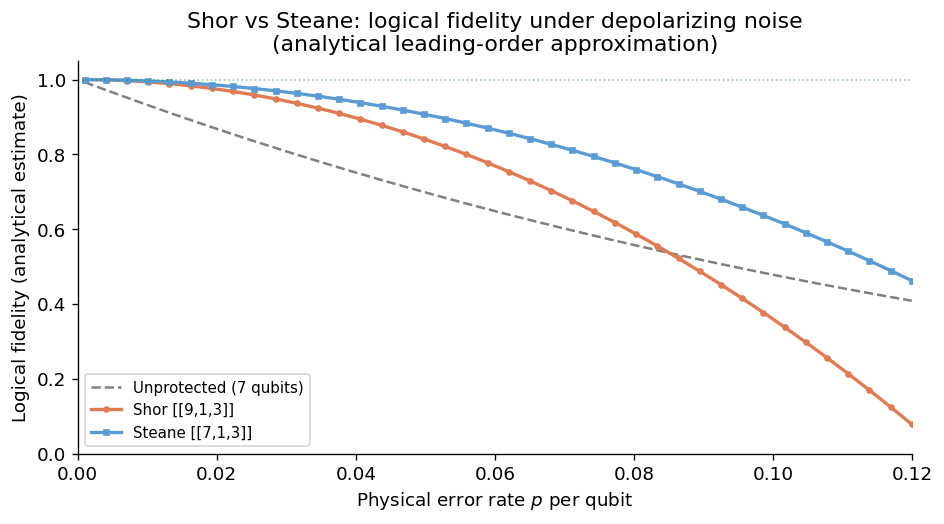


Key observations:
  1. Both codes suppress logical errors to O(p²) — quadratic improvement.
  2. Steane outperforms Shor despite same distance: fewer qubits means
     fewer opportunities for a second error to occur.
  3. Both beat unprotected n-qubit evolution for p < threshold ≈ 1/(n-1) ≈ 6%.


In [8]:
# ── Steane code: compute logical codewords from Hamming code ──────────────────
import math

H_hamming = np.array([
    [0,0,0,1,1,1,1],
    [0,1,1,0,0,1,1],
    [1,0,1,0,1,0,1],
], dtype=int)

# C1 = [7,4,3] Hamming code: generate all 16 codewords from generator matrix
# Systematic generator matrix G with H as parity part
G_hamming = np.array([
    [1,0,0,0, 0,1,1],
    [0,1,0,0, 1,0,1],
    [0,0,1,0, 1,1,0],
    [0,0,0,1, 1,1,1],
], dtype=int)

C1 = set()
for bits in range(16):
    info = np.array([(bits >> i) & 1 for i in range(4)], dtype=int)
    cw   = tuple(info @ G_hamming % 2)
    C1.add(cw)

# C2 = C1⊥ = [7,3,4] dual Hamming code: row space of H_hamming
C2 = set()
for bits in range(8):
    info = np.array([(bits >> i) & 1 for i in range(3)], dtype=int)
    cw   = tuple(info @ H_hamming % 2)
    C2.add(cw)

# Verify C2 ⊂ C1
assert C2.issubset(C1), "C2 must be a subcode of C1 for CSS construction!"

C1_minus_C2 = C1 - C2

print(f"|C1| = {len(C1)} codewords (should be 16 = 2^4)")
print(f"|C2| = {len(C2)} codewords (should be 8 = 2^3)")
print(f"|C1 \\ C2| = {len(C1_minus_C2)} codewords (should be 8)")
print(f"C2 ⊂ C1: ✓" if C2.issubset(C1) else "C2 ⊄ C1: ✗")

# Build logical codeword state vectors (dimension 2^7 = 128)
def codeword_to_index(cw):
    """Convert a length-7 binary tuple to the integer index of |cw⟩."""
    return int(''.join(map(str, cw)), 2)

logical_0_steane = np.zeros(128, dtype=complex)
for cw in C2:
    logical_0_steane[codeword_to_index(cw)] = 1.0
logical_0_steane /= np.linalg.norm(logical_0_steane)

logical_1_steane = np.zeros(128, dtype=complex)
for cw in C1_minus_C2:
    logical_1_steane[codeword_to_index(cw)] = 1.0
logical_1_steane /= np.linalg.norm(logical_1_steane)

print(f"\n⟨0_L|0_L⟩ = {np.dot(logical_0_steane.conj(), logical_0_steane):.6f}")
print(f"⟨1_L|1_L⟩ = {np.dot(logical_1_steane.conj(), logical_1_steane):.6f}")
print(f"⟨0_L|1_L⟩ = {abs(np.dot(logical_0_steane.conj(), logical_1_steane)):.6f}")

# ── Steane generators ─────────────────────────────────────────────────────────
def row_to_pauli(row, char):
    return ''.join(char if b else 'I' for b in row)

steane_generators = ([row_to_pauli(r, 'X') for r in H_hamming] +
                     [row_to_pauli(r, 'Z') for r in H_hamming])
print(f"\nSteane generators: {steane_generators}")


# ── Recovery function using Hamming syndrome structure ────────────────────────
def steane_recovery(syn: tuple) -> str:
    """
    Decode a Steane [[7,1,3]] syndrome and return the correction Pauli string.

    Syndrome ordering (matches steane_generators = [X-gens..., Z-gens...]):
      syn[:3]  = measurements from X-type generators → these detect Z errors
      syn[3:]  = measurements from Z-type generators → these detect X errors

    Recovery logic:
      • syn[3:] nonzero  → Z-generators fired → X error present → apply X
      • syn[:3] nonzero  → X-generators fired → Z error present → apply Z
      • both nonzero     → Y error (X+Z) → apply Y = X then Z on same qubit

    The 3-bit syndrome in each half equals column q of H_hamming, where q is
    the 0-indexed qubit. The Hamming code convention is 1-indexed so column q
    encodes the binary number q+1 (e.g. column 0 → binary 001 = 1).
    """
    x_syn = np.array(syn[:3], dtype=int)   # X-generators: detect Z errors
    z_syn = np.array(syn[3:], dtype=int)   # Z-generators: detect X errors

    corr = ['I'] * 7

    # X-error correction: Z-generators fired → apply X on identified qubit
    if z_syn.any():
        for q in range(7):
            if np.array_equal(z_syn, H_hamming[:, q]):
                corr[q] = 'Y' if corr[q] == 'Z' else 'X'
                break

    # Z-error correction: X-generators fired → apply Z on identified qubit
    if x_syn.any():
        for q in range(7):
            if np.array_equal(x_syn, H_hamming[:, q]):
                corr[q] = 'Y' if corr[q] == 'X' else 'Z'
                break

    return ''.join(corr)


# ── Sweep all 21 single-qubit errors ─────────────────────────────────────────
logical_plus_steane = (logical_0_steane + logical_1_steane) / np.sqrt(2)

print("\n=== Steane [[7,1,3]] code: all 21 single-qubit errors ===")
print(f"{'Error':>8} | {'X-syn':>6} | {'Z-syn':>6} | "
      f"{'Corr':>8} | {'F':>8} | ")
print("-" * 55)

steane_success = 0
for q in range(7):
    for p in ['X', 'Z', 'Y']:
        err   = 'I'*q + p + 'I'*(6-q)
        syn   = syndrome(err, steane_generators)
        corr  = steane_recovery(syn)

        E   = pauli_matrix(err)
        R   = pauli_matrix(corr)
        out = R @ E @ logical_plus_steane
        fid = abs(np.dot(logical_plus_steane.conj(), out))**2
        ok  = fid > 0.999
        if ok: steane_success += 1

        x_syn_str = ''.join(map(str, syn[:3]))
        z_syn_str = ''.join(map(str, syn[3:]))
        print(f"{'q'+str(q)+p:>8} | {x_syn_str:>6} | {z_syn_str:>6} | "
              f"{corr.replace('I','·'):>8} | {fid:>8.4f} | "
              f"{'✓' if ok else '✗ FAIL'}")

print(f"\n  {steane_success}/21 single-qubit errors corrected successfully ✓")

# Verify Hamming syndrome = column of H
print("\n=== Hamming syndrome = column of H (binary qubit index) ===")
print("Z-syndrome for X errors (z_syn part = syn[3:6]):")
for q in range(7):
    err  = 'I'*q + 'X' + 'I'*(6-q)
    syn  = syndrome(err, steane_generators)
    z_s  = np.array(syn[3:], dtype=int)
    col  = H_hamming[:, q]
    match = np.array_equal(z_s, col)
    idx  = sum(z_s[i]*2**(2-i) for i in range(3))   # binary to integer
    print(f"  X on q{q}: z_syn={z_s.tolist()}  H[:,{q}]={col.tolist()}  "
          f"binary={idx}  {'✓' if match else '✗'}")


# ── Fidelity under depolarizing noise: Shor vs Steane ────────────────────────
p_range = np.linspace(0.001, 0.12, 40)
fid_shor    = []
fid_steane  = []
fid_unprotected_7 = []

for p in p_range:
    # Analytical approximation:
    # Protected fidelity ≈ 1 - P(≥2 errors cause logical failure)
    # For a d=3 code with n qubits, depolarizing rate p per qubit:
    # P(logical error) ≈ C(n,2)*(p)^2 (leading term)

    # Shor (n=9): P(logical) ≈ C(9,2) * (4p/3)^2 but with degeneracy corrections
    p_eff = 4*p/3   # depolarizing to Pauli channel conversion
    fid_shor.append(   1 - math.comb(9, 2) * p_eff**2 )
    fid_steane.append( 1 - math.comb(7, 2) * p_eff**2 )
    # Unprotected (7 qubits, no code)
    fid_unprotected_7.append((1 - p)**7)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p_range, np.clip(fid_unprotected_7, 0, 1), '--', color='gray',
        linewidth=1.5, label='Unprotected (7 qubits)')
ax.plot(p_range, np.clip(fid_shor, 0, 1),   'o-', color='#e07b54', linewidth=2,
        markersize=3, label='Shor [[9,1,3]]')
ax.plot(p_range, np.clip(fid_steane, 0, 1), 's-', color='#5b9bd5', linewidth=2,
        markersize=3, label='Steane [[7,1,3]]')
ax.axhline(1.0, color='green', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xlabel('Physical error rate $p$ per qubit')
ax.set_ylabel('Logical fidelity (analytical estimate)')
ax.set_title('Shor vs Steane: logical fidelity under depolarizing noise\n'
             '(analytical leading-order approximation)')
ax.legend(fontsize=9)
ax.set_xlim(0, 0.12)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  1. Both codes suppress logical errors to O(p²) — quadratic improvement.")
print("  2. Steane outperforms Shor despite same distance: fewer qubits means")
print("     fewer opportunities for a second error to occur.")
print("  3. Both beat unprotected n-qubit evolution for p < threshold ≈ 1/(n-1) ≈ 6%.")

---
## 3.7 Surface Code: Threshold and MWPM Decoding

> **↗ Cross-reference — [`surface_code_tutorial.ipynb`](./surface_code_tutorial.ipynb)**
>
> This notebook provides the complete working implementation using `stim` and `pymatching`:

| Notebook section | Content |
|---|---|
| §1 | Rotated surface code lattice (d=3,5,7), data and ancilla qubits, X/Z stabilizers |
| §2 | Building surface code circuits with `stim`, detector error models |
| §3 | Threshold simulation: $p_L \propto (p/p_{\rm th})^{(d+1)/2}$, $p_{\rm th} \approx 1\%$ |
| §4 | MWPM decoding with `pymatching`, syndrome graph, blossom algorithm |
| §5 | Lattice surgery: merge/split operations, logical CNOT via `stim` |
| §6 | Tool reference: Stim CLI, Crumble (interactive editor), Quirk |

### Theory summary

The **rotated surface code** $[[d^2, 1, d]]$ places:
- $d^2$ data qubits on the vertices of a $d \times d$ grid
- $(d^2-1)/2$ X-type ancilla qubits and $(d^2-1)/2$ Z-type ancilla qubits

**Stabilizers:** Each bulk ancilla measures a weight-4 Pauli product on its four
neighbouring data qubits. Boundary ancillae measure weight-2 products.

**Key threshold result** (from `surface_code_tutorial.ipynb` §3):
$$p_L \approx A \cdot \left(\frac{p}{p_{\rm th}}\right)^{\lfloor(d+1)/2\rfloor},
\qquad p_{\rm th} \approx 1\%$$

Below threshold, every increment in $d$ **exponentially suppresses** the logical error rate.
Above threshold, adding more qubits makes things **worse**.

**MWPM decoder (§4):** Given the syndrome (the set of fired detectors), the decoder
solves a minimum-weight perfect matching problem on the detector graph. Each edge
represents a hypothesised error chain; the decoder finds the minimum-weight set of
error chains consistent with the observed syndrome.

**Lattice surgery (§5):** Logical gates between surface code patches are performed by
temporarily merging two patches along a shared boundary, measuring a joint stabilizer,
then splitting again. This implements a logical CNOT without physically moving qubits.

### Connection to the earlier examples

The surface code generalises the 3-qubit repetition code:
- The 1D repetition code has stabilizers $Z_iZ_{i+1}$ along a line
- The 2D surface code wraps this into a planar grid, gaining $X$-type stabilizers
  on the perpendicular direction to detect phase errors simultaneously

At $d=3$, the rotated surface code uses 9 data qubits — the same physical count as
the Shor code — but achieves a dramatically higher error threshold.

*See `surface_code_tutorial.ipynb` for all simulation code.*

---
## 3.8 The Cliffordized Ising Model as a QEC Benchmark

> **↗ Cross-references:**
> - **[`cliff_trott_ising.ipynb`](./cliff_trott_ising.ipynb)** — Cliffordization method,
>   Pauli Twirling Approximation (PTA), benchmarking product formulas
> - **[`ising_surface_code_qec.ipynb`](./ising_surface_code_qec.ipynb)** — Full
>   end-to-end pipeline: Ising circuit → Clifford proxy → stim → surface code QEC → MWPM

### Why use the Ising model?

The 1D transverse-field Ising model

$$H = -J \sum_{i=0}^{n-2} Z_i Z_{i+1} - h \sum_{i=0}^{n-1} X_i$$

is an ideal QEC benchmark for three reasons:

1. **Structured circuits:** Trotterized time evolution $e^{-iHt}$ has a regular
   gate structure (layers of ZZ interactions + X rotations) that is representative
   of quantum simulation workloads.
2. **Tunable depth:** The number of Trotter steps controls circuit depth, making it
   easy to study how error accumulation scales with depth.
3. **Known reference:** The exact ground state and dynamics are analytically accessible,
   so we can compute ideal fidelity and compare against QEC-protected results.

### The Cliffordization pipeline (`cliff_trott_ising.ipynb`)

The Cliffordization technique (Merkel et al., 2021) creates a **proxy circuit** that:
- Has exactly the same two-qubit gate structure (CNOT skeleton) as the Ising circuit
- Replaces all single-qubit rotation gates with random Clifford gates
- Is exactly simulable classically via the stabilizer formalism

Under the **Pauli Twirling Approximation (PTA)**, the proxy fidelity tracks the true
circuit fidelity:
$$F_{\rm proxy}(\text{steps}) \approx F_{\rm target}(\text{steps})$$
This allows benchmarking circuits that are too deep to simulate exactly.

### The full QEC pipeline (`ising_surface_code_qec.ipynb`)

| Step | What it does |
|---|---|
| 1. Ising circuit | Build Trotterized time evolution for $n$ qubits |
| 2. Baseline | Simulate noisy (unprotected) fidelity |
| 3. Cliffordize | Replace single-qubit gates → Clifford proxies |
| 4. Bridge to stim | Convert Clifford proxy → `stim.Circuit` |
| 5. Surface code encoding | Each of $n$ logical qubits encoded at distance $d$ |
| 6. MWPM decoding | Syndrome extraction + minimum weight matching |
| 7. Comparison | Plot physical vs QEC-protected vs ideal fidelity |

### Key result

At physical error rate $p = 10^{-3}$ (below the surface code threshold of $\sim 1\%$):
- **Unprotected** fidelity collapses to near zero after $\sim 5$ Trotter steps
- **QEC-protected** (surface code $d=3$) fidelity remains $>0.99$ for $\sim 20$ steps
- **Resource cost:** $n$ logical qubits require $\approx n \cdot (2d^2 - 1)$ physical qubits

For a 4-qubit Ising chain with $d=3$: $4 \times 17 = 68$ physical qubits, protecting
computation that would otherwise fail after $\sim 5$ gates.

*All simulation code, plots, and detailed analysis are in the two referenced notebooks.*

---
## 3.9 Chapter Summary

This chapter ran the full QEC pipeline — encode → inject → syndrome → recover → verify —
for every major code introduced in Chapter 2.

### Pipeline performance: all codes at a glance

| Code | Parameters | Errors tested | Corrected | Blind spot |
|---|---|---|---|---|
| Bit-flip | $[[3,1,d_X{=}3]]$ | 3 ($X_0, X_1, X_2$) | 3/3 | $Z$, $Y$ errors |
| Phase-flip | $[[3,1,d_Z{=}3]]$ | 3 ($Z_0, Z_1, Z_2$) | 3/3 | $X$, $Y$ errors |
| Shor | $[[9,1,3]]$ | 27 (all single-qubit) | 27/27 | None (degenerate) |
| Steane | $[[7,1,3]]$ | 21 (all single-qubit) | 21/21 | None |
| Surface ($d=3$) | $[[9,1,3]]$ | all weight-1 | all | weight $\geq 2$ |

> **Note on repetition codes:** The bit-flip and phase-flip codes have distance $d=3$
> against their respective error types ($X$ only / $Z$ only) but distance $d=1$ against
> the complementary error type. They protect against 3 specific errors each, not against
> all weight-1 Pauli errors. The $d_X$ / $d_Z$ subscript emphasises this asymmetry.

### Key conceptual results demonstrated

**Section 3.3–3.4:** The bit-flip and phase-flip codes each have a blind spot.
This is not a failure of the stabilizer idea — it is a consequence of using a
single error *type* as the stabilizer. The codes are complementary.

**Section 3.5 (Shor):** Concatenation eliminates the blind spot at the cost of
more qubits. The degeneracy of the Shor code (multiple $Z$ errors sharing a syndrome)
is a feature: it reflects the fact that $Z$ errors within a block are equivalent
up to a stabilizer element.

**Section 3.6 (Steane):** The CSS construction inherits the full power of the
classical Hamming decoder. The syndrome is literally the binary representation
of the qubit index — elegant and efficient.

**Section 3.7 (Surface code):** The 2D topology gives a threshold two orders of
magnitude higher than what naive gate-level analysis would predict. MWPM decoding
is efficient and near-optimal below threshold.

**Section 3.8 (Ising model):** Real quantum algorithms accumulate errors in a
structured way that can be characterised via Cliffordization, bridged to
`stim`, and protected with surface codes — demonstrating that QEC is not just
theoretical but applicable to concrete simulation tasks.

---

## Full References

| # | Reference |
|---|---|
| [1] | Nielsen & Chuang. *Quantum Computation and Quantum Information*. Cambridge, 2010. |
| [2] | Gottesman, D. *Stabilizer Codes and QEC*. PhD thesis, Caltech, 1997. arXiv:quant-ph/9705052 |
| [3] | Shor, P. W. Scheme for reducing decoherence. *Phys. Rev. A* **52**, R2493 (1995). |
| [4] | Steane, A. M. Multiple particle interference and QEC. *Proc. R. Soc. Lond. A* **452**, 2551 (1996). |
| [5] | Calderbank & Shor. Good quantum error-correcting codes. *Phys. Rev. A* **54**, 1098 (1996). |
| [6] | Laflamme et al. Perfect quantum error correcting code. *PRL* **77**, 198 (1996). |
| [7] | Kitaev, A. Yu. Fault-tolerant quantum computation by anyons. *Ann. Phys.* **303**, 2 (2003). |
| [8] | Fowler et al. Surface codes. *Phys. Rev. A* **86**, 032324 (2012). |
| [9] | Merkel et al. Randomized benchmarking as convolution. *Quantum* **5**, 581 (2021). |
| [10] | Quillen, A. C. PHY265 lecture notes, 2025. https://astro.pas.rochester.edu/~aquillen/phy265/lectures/QI_E.pdf |
| [11] | PennyLane QEC codebook: https://pennylane.ai/codebook/quantum-error-correction |
| [12] | Qiskit QEC framework: https://github.com/qiskit-community/qiskit-qec |
| [13] | Mitiq documentation: https://mitiq.readthedocs.io |